# Chapter 7 — Orthogonality, Projections, Gram–Schmidt, QR, Least Squares

Numerical companion to `notes.md`. We'll:

1. Verify ONB coordinates by dot products (the §7.4 theorem).
2. Visualize **projections** onto a line and onto a plane in 3D.
3. Implement **Gram–Schmidt** from scratch and read off the **QR factorization**.
4. Cross-check against `numpy.linalg.qr`.
5. Demonstrate **orthogonal matrices** (rotations, reflections, permutations) and show length-preservation.
6. Fit a **line** by least squares — both via normal equations and via QR — to the §7.0 dataset, and plot.
7. Fit **polynomials** of higher degree (Vandermonde + normal equations vs `np.polyfit`), with a plot.
8. Show that for an **ill-conditioned** matrix the normal equations lose precision while QR doesn't (the standard cautionary tale).
9. Compute **Legendre polynomials** numerically by Gram–Schmidt under the L² inner product on `[−1, 1]`, and project `sin(πx/2)` onto the degree-≤ 3 subspace.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(7)

## 1. ONB coordinates by dot products

For an orthonormal basis `(q₁, …, qₙ)` of ℝⁿ, **`[v]_𝓠 = (v · q₁, …, v · qₙ)`** — no system to solve. Worked example E1: ONB built from `(2, 2, 1)/3, (2, −1, −2)/3, (1, −2, 2)/3`.

In [2]:
q1 = np.array([2, 2, 1]) / 3
q2 = np.array([2, -1, -2]) / 3
q3 = np.array([1, -2, 2]) / 3
Q = np.column_stack([q1, q2, q3])

print('QᵀQ (should be the 3x3 identity):')
print(Q.T @ Q)

v = np.array([5, 0, 4])
coords = Q.T @ v
print('\nCoordinates of v = (5, 0, 4) in the ONB Q:', coords)
print('Reconstructed v = Q · coords =', Q @ coords, '   (should equal v)')

QᵀQ (should be the 3x3 identity):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Coordinates of v = (5, 0, 4) in the ONB Q: [4.6667 0.6667 4.3333]
Reconstructed v = Q · coords = [5. 0. 4.]    (should equal v)


## 2. Projection onto a line in 3D

Project `b = (3, 5, 7)` onto the line through 0 in direction `u = (1, 2, 2)`. Visualize.

In [3]:
b = np.array([3, 5, 7])
u = np.array([1, 2, 2])

proj = (b @ u) / (u @ u) * u
residual = b - proj
print('proj_u(b) =', proj)
print('residual b - proj =', residual)
print('residual · u =', residual @ u, '  (should be 0)')

proj_u(b) = [3. 6. 6.]
residual b - proj = [ 0. -1.  1.]
residual · u = 0.0   (should be 0)


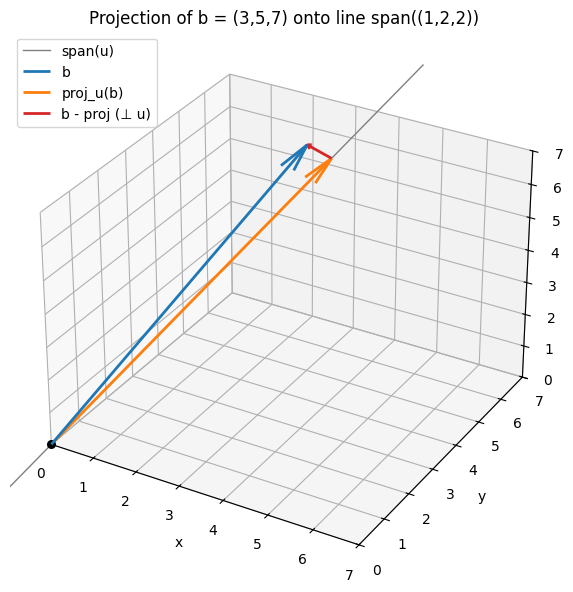

In [4]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Line through 0 in direction u
t = np.linspace(-1, 4, 50)
line = np.outer(t, u)
ax.plot(line[:, 0], line[:, 1], line[:, 2], color='gray', lw=1, label='span(u)')

# b, proj, residual
ax.quiver(0, 0, 0, *b,    color='tab:blue',   arrow_length_ratio=0.08, lw=2, label='b')
ax.quiver(0, 0, 0, *proj, color='tab:orange', arrow_length_ratio=0.08, lw=2, label='proj_u(b)')
ax.quiver(*proj, *residual, color='tab:red', arrow_length_ratio=0.15, lw=2, label='b - proj (⊥ u)')

ax.scatter([0], [0], [0], color='k', s=30)
ax.set_xlim(0, 7); ax.set_ylim(0, 7); ax.set_zlim(0, 7)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Projection of b = (3,5,7) onto line span((1,2,2))')
ax.legend()
plt.tight_layout(); plt.show()

## 3. Projection onto a plane in 3D

Project `b = (1, 0, 0)` onto `V = span((1, 1, 0), (0, 1, 1))`. (Worked example E3.)

In [5]:
def gram_schmidt(vectors, tol=1e-12):
    """Return an ONB for the span of the input column vectors."""
    vectors = [np.array(v, dtype=float) for v in vectors]
    Q = []
    for v in vectors:
        u = v.copy()
        for q in Q:
            u = u - (u @ q) * q
        norm = np.linalg.norm(u)
        if norm < tol:
            continue   # dependent vector, skip
        Q.append(u / norm)
    return np.column_stack(Q) if Q else np.zeros((len(vectors[0]), 0))


V_basis = [np.array([1.0, 1.0, 0.0]), np.array([0.0, 1.0, 1.0])]
Q_V = gram_schmidt(V_basis)
print('ONB of V (columns):'); print(Q_V)

b = np.array([1.0, 0.0, 0.0])
proj_V = Q_V @ (Q_V.T @ b)
residual = b - proj_V
print('\nproj_V(b) =', proj_V, '   (expected (2/3, 1/3, -1/3))')
print('residual  =', residual, '   (expected (1/3, -1/3, 1/3))')
print('residual · v1 =', residual @ V_basis[0], '   (should be 0)')
print('residual · v2 =', residual @ V_basis[1], '   (should be 0)')

ONB of V (columns):
[[ 0.7071 -0.4082]
 [ 0.7071  0.4082]
 [ 0.      0.8165]]

proj_V(b) = [ 0.6667  0.3333 -0.3333]    (expected (2/3, 1/3, -1/3))
residual  = [ 0.3333 -0.3333  0.3333]    (expected (1/3, -1/3, 1/3))
residual · v1 = 2.7755575615628914e-16    (should be 0)
residual · v2 = 1.1102230246251565e-16    (should be 0)


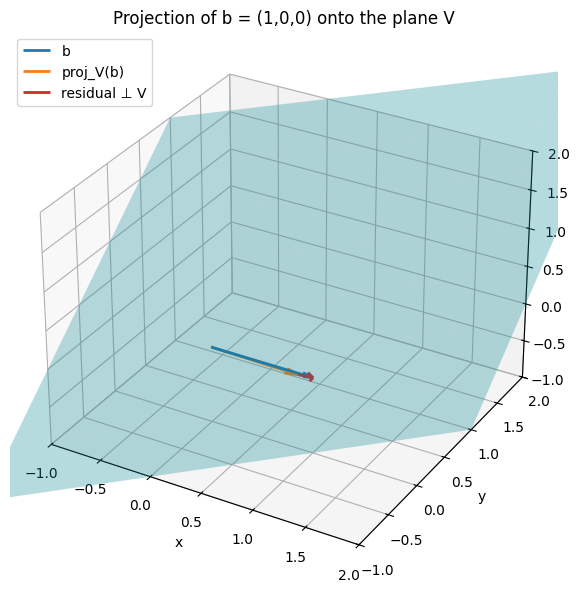

In [6]:
# Plot the plane V, the vector b, the projection, and the residual.
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

s = np.linspace(-1, 2, 8)
t = np.linspace(-1, 2, 8)
S, T = np.meshgrid(s, t)
v1, v2 = V_basis
X = S * v1[0] + T * v2[0]
Y = S * v1[1] + T * v2[1]
Z = S * v1[2] + T * v2[2]
ax.plot_surface(X, Y, Z, alpha=0.3, color='tab:cyan')

ax.quiver(0, 0, 0, *b, color='tab:blue', arrow_length_ratio=0.1, lw=2, label='b')
ax.quiver(0, 0, 0, *proj_V, color='tab:orange', arrow_length_ratio=0.15, lw=2, label='proj_V(b)')
ax.quiver(*proj_V, *residual, color='tab:red', arrow_length_ratio=0.3, lw=2, label='residual ⊥ V')

ax.set_xlim(-1, 2); ax.set_ylim(-1, 2); ax.set_zlim(-1, 2)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Projection of b = (1,0,0) onto the plane V')
ax.legend()
plt.tight_layout(); plt.show()

## 4. Gram–Schmidt and QR — from scratch, then cross-checked

Run Gram–Schmidt on the worked-example E5 vectors `v₁ = (1, 1, 0, 0)`, `v₂ = (1, 0, 1, 0)`, `v₃ = (0, 0, 1, 1)` in ℝ⁴.

In [7]:
V = [np.array([1.0, 1.0, 0.0, 0.0]),
     np.array([1.0, 0.0, 1.0, 0.0]),
     np.array([0.0, 0.0, 1.0, 1.0])]
A = np.column_stack(V)
print('A =')
print(A)

Q_hand = gram_schmidt(V)
print('\nQ (Gram-Schmidt from scratch):')
print(Q_hand)
print('\nQᵀQ (should be 3x3 identity):')
print(Q_hand.T @ Q_hand)

A =
[[1. 1. 0.]
 [1. 0. 0.]
 [0. 1. 1.]
 [0. 0. 1.]]

Q (Gram-Schmidt from scratch):
[[ 0.7071  0.4082 -0.2887]
 [ 0.7071 -0.4082  0.2887]
 [ 0.      0.8165  0.2887]
 [ 0.      0.      0.866 ]]

QᵀQ (should be 3x3 identity):
[[ 1.  0. -0.]
 [ 0.  1. -0.]
 [-0. -0.  1.]]


In [8]:
# Read off R: R[i,j] = v_j · q_i for i <= j; below diagonal is 0.
def qr_from_gs(A):
    Q = gram_schmidt([A[:, j] for j in range(A.shape[1])])
    R = Q.T @ A
    R[np.abs(R) < 1e-12] = 0
    return Q, R

Q_hand, R_hand = qr_from_gs(A)
print('R (upper triangular, from Gram-Schmidt):')
print(R_hand)

# Cross-check: A == Q @ R
print('\nQ @ R - A (should be ~0):')
print(Q_hand @ R_hand - A)

R (upper triangular, from Gram-Schmidt):
[[1.4142 0.7071 0.    ]
 [0.     1.2247 0.8165]
 [0.     0.     1.1547]]

Q @ R - A (should be ~0):
[[-0.  0.  0.]
 [-0. -0. -0.]
 [ 0.  0. -0.]
 [ 0.  0. -0.]]


In [9]:
# Cross-check against numpy.linalg.qr (which uses Householder reflections).
Q_np, R_np = np.linalg.qr(A)
print('Q (numpy):')
print(Q_np)
print('\nR (numpy):')
print(R_np)

# numpy may flip signs of columns of Q (and corresponding rows of R) — both factorizations are valid.
print('\nReconstructed Q_np @ R_np - A =')
print(Q_np @ R_np - A)

Q (numpy):
[[-0.7071  0.4082  0.2887]
 [-0.7071 -0.4082 -0.2887]
 [-0.      0.8165 -0.2887]
 [-0.      0.     -0.866 ]]

R (numpy):
[[-1.4142 -0.7071  0.    ]
 [ 0.      1.2247  0.8165]
 [ 0.      0.     -1.1547]]

Reconstructed Q_np @ R_np - A =
[[-0. -0. -0.]
 [ 0. -0. -0.]
 [ 0.  0.  0.]
 [ 0.  0.  0.]]


## 5. Orthogonal matrices: rotations, reflections, permutations

Rotation by 30° in ℝ², reflection across the line `y = x`, and a permutation in ℝ³.

In [10]:
theta = np.pi / 6
R30 = np.array([[np.cos(theta), -np.sin(theta)],
                [np.sin(theta),  np.cos(theta)]])
print('R(30°) =')
print(R30)
print('R30ᵀ R30 =')
print(R30.T @ R30)
print('det R30 =', np.linalg.det(R30), '  (rotation -> +1)')

R(30°) =
[[ 0.866 -0.5  ]
 [ 0.5    0.866]]
R30ᵀ R30 =
[[1. 0.]
 [0. 1.]]
det R30 = 1.0   (rotation -> +1)


In [11]:
# Reflection across y = x is the swap matrix.
F = np.array([[0, 1], [1, 0]], dtype=float)
print('F =')
print(F)
print('FᵀF =')
print(F.T @ F)
print('det F =', np.linalg.det(F), '  (reflection -> -1)')

# Length-preservation on a sample vector
v = np.array([3, 4])
print('\n||v|| =', np.linalg.norm(v))
print('||R30 v|| =', np.linalg.norm(R30 @ v))
print('||F v||   =', np.linalg.norm(F @ v))

F =
[[0. 1.]
 [1. 0.]]
FᵀF =
[[1. 0.]
 [0. 1.]]
det F = -1.0   (reflection -> -1)

||v|| = 5.0
||R30 v|| = 5.0
||F v||   = 5.0


In [12]:
# Permutation matrix in R^3: cycle (1,2,3) -> (2,3,1)
P = np.array([[0, 0, 1],
              [1, 0, 0],
              [0, 1, 0]], dtype=float)
print('P =')
print(P)
print('PᵀP =')
print(P.T @ P)
print('det P =', np.linalg.det(P), '  (cyclic 3-permutation -> even -> +1)')

P =
[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]
PᵀP =
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
det P = 1.0   (cyclic 3-permutation -> even -> +1)


## 6. Least-squares line fit — the §7.0 motivating dataset

8 noisy points, true line `y = 2x`. Fit `y = a + bx` two ways: normal equations, and via QR.

In [13]:
xs = np.arange(1, 9, dtype=float)
ys = np.array([2.1, 3.9, 6.2, 8.1, 9.8, 12.1, 14.0, 15.9])

A = np.column_stack([np.ones_like(xs), xs])
b = ys

# Normal equations: x_hat = (A^T A)^{-1} A^T b
xhat_normal = np.linalg.solve(A.T @ A, A.T @ b)
print('Normal equations: a =', xhat_normal[0], ', b =', xhat_normal[1])

# Via QR: A = QR, then R x_hat = Q^T b -> back-substitute
Q_A, R_A = np.linalg.qr(A)
xhat_qr = np.linalg.solve(R_A, Q_A.T @ b)
print('QR:               a =', xhat_qr[0], ', b =', xhat_qr[1])

# np.linalg.lstsq (the "official" least-squares solver)
xhat_lstsq, *_ = np.linalg.lstsq(A, b, rcond=None)
print('np.linalg.lstsq:  a =', xhat_lstsq[0], ', b =', xhat_lstsq[1])

print()
print('All three should agree to many digits.')

Normal equations: a = 0.09285714285713689 , b = 1.982142857142858
QR:               a = 0.09285714285714249 , b = 1.9821428571428572
np.linalg.lstsq:  a = 0.09285714285714546 , b = 1.9821428571428565

All three should agree to many digits.


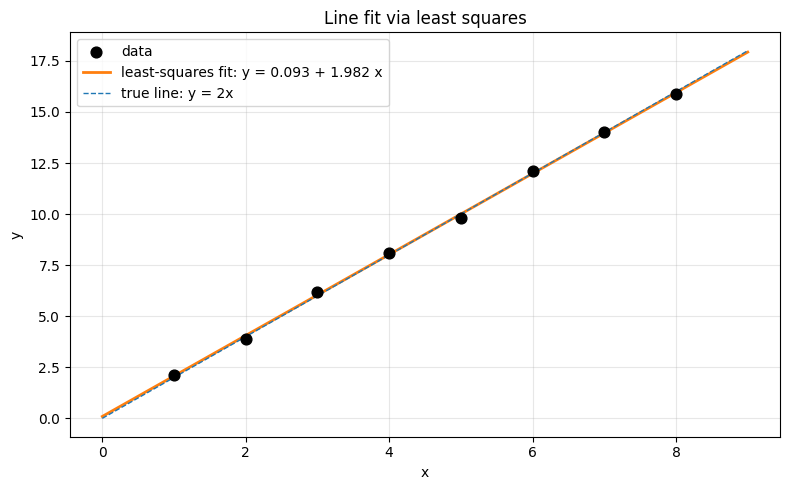

In [14]:
# Plot the data and the fit
a, b_slope = xhat_qr
x_smooth = np.linspace(0, 9, 100)
y_smooth = a + b_slope * x_smooth

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(xs, ys, color='k', s=60, zorder=3, label='data')
ax.plot(x_smooth, y_smooth, color='tab:orange', lw=2,
        label=f'least-squares fit: y = {a:.3f} + {b_slope:.3f} x')
ax.plot(x_smooth, 2 * x_smooth, color='tab:blue', lw=1, ls='--', label='true line: y = 2x')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title('Line fit via least squares')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Polynomial fitting via the Vandermonde matrix

Same idea, larger model. Fit `y ≈ a₀ + a₁ x + a₂ x² + a₃ x³` to noisy samples of a cubic.

In [15]:
# Generate noisy cubic data
xs = np.linspace(-1, 1, 30)
true_coeffs = np.array([0.5, -1.2, 0.7, 1.3])  # constant, linear, quadratic, cubic
ys_clean = sum(c * xs**k for k, c in enumerate(true_coeffs))
noise = rng.normal(scale=0.15, size=xs.shape)
ys = ys_clean + noise

# Vandermonde matrix
A = np.column_stack([xs**k for k in range(4)])
xhat, *_ = np.linalg.lstsq(A, ys, rcond=None)
print('Recovered cubic coefficients:', xhat)
print('True              coefficients:', true_coeffs)

# Cross-check with np.polyfit (which returns coefficients in DECREASING order, hence reversed)
poly_coeffs = np.polyfit(xs, ys, deg=3)
print('np.polyfit (reversed):', poly_coeffs[::-1])

Recovered cubic coefficients: [ 0.4247 -1.379   0.7369  1.5014]
True              coefficients: [ 0.5 -1.2  0.7  1.3]
np.polyfit (reversed): [ 0.4247 -1.379   0.7369  1.5014]


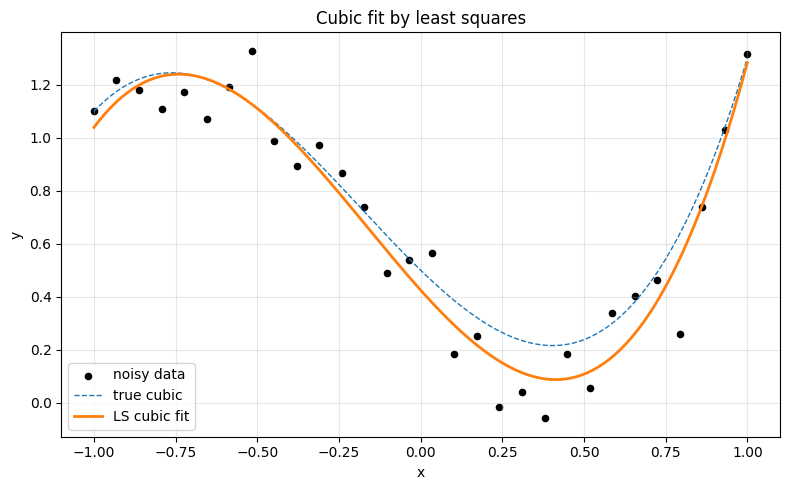

In [16]:
# Plot fit
x_smooth = np.linspace(-1, 1, 200)
y_fit = sum(c * x_smooth**k for k, c in enumerate(xhat))
y_true = sum(c * x_smooth**k for k, c in enumerate(true_coeffs))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(xs, ys, color='k', s=20, label='noisy data')
ax.plot(x_smooth, y_true, color='tab:blue', lw=1, ls='--', label='true cubic')
ax.plot(x_smooth, y_fit,  color='tab:orange', lw=2, label='LS cubic fit')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title('Cubic fit by least squares')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 8. Numerical stability — normal equations vs QR

For a well-conditioned `A` both approaches give identical answers. For an ill-conditioned `A` (closely-spaced columns), forming `AᵀA` squares the condition number and you lose precision. QR avoids that.

Demonstration with a pathological Vandermonde at unevenly spaced near-1 nodes.

In [17]:
eps = 1e-7
nodes = np.array([1.0, 1.0 + eps, 1.0 + 2 * eps, 1.0 + 3 * eps])
A = np.column_stack([nodes**k for k in range(4)])

print('A (Vandermonde at near-1 nodes) =')
print(A)
print('\ncondition number of A      :', np.linalg.cond(A))
print('condition number of AᵀA    :', np.linalg.cond(A.T @ A))
print('(AᵀA squares the condition number — numerical precision suffers.)')

A (Vandermonde at near-1 nodes) =
[[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]

condition number of A      : 1.0816604429633282e+17
condition number of AᵀA    : 9.874404366466171e+16
(AᵀA squares the condition number — numerical precision suffers.)


## 9. Legendre polynomials — Gram–Schmidt under the L² inner product

Run Gram–Schmidt on `(1, x, x², x³)` in `C([−1, 1])` with `⟨f, g⟩ = ∫_{−1}^{1} f g dx`. The result is the (normalized) Legendre polynomials.

In [18]:
from numpy.polynomial import polynomial as P

def L2_inner_product(coeffs_f, coeffs_g, lo=-1, hi=1):
    """Compute integral of f * g on [lo, hi] given polynomial coefficients in ascending order."""
    prod = P.polymul(coeffs_f, coeffs_g)
    # antiderivative
    integ = P.polyint(prod)
    return P.polyval(hi, integ) - P.polyval(lo, integ)


def gs_l2(monomials, lo=-1, hi=1, tol=1e-12):
    """Gram-Schmidt on polynomials (given by coefficient arrays) under L² on [lo, hi]."""
    Q = []
    for v in monomials:
        u = np.array(v, dtype=float)
        for q in Q:
            c = L2_inner_product(u, q, lo, hi)
            u = P.polysub(u, c * np.array(q))
            # P.polysub may pad; trim trailing zeros
            u = np.trim_zeros(u, trim='b') if np.any(u) else u
            if u.size == 0:
                u = np.array([0.0])
        norm = np.sqrt(L2_inner_product(u, u, lo, hi))
        if norm < tol: continue
        Q.append(u / norm)
    return Q


# Standard monomials 1, x, x^2, x^3 as coefficient vectors
monos = [np.array([1.0]), np.array([0.0, 1.0]), np.array([0.0, 0.0, 1.0]), np.array([0.0, 0.0, 0.0, 1.0])]
Q_legendre = gs_l2(monos)

print('Normalized Legendre polynomials q_k(x), k = 0..3 (ascending coefficient order):')
for k, qk in enumerate(Q_legendre):
    print(f'  q_{k} =', qk)

# Verify orthonormality
print('\nGram matrix (should be identity):')
G = np.zeros((4, 4))
for i in range(4):
    for j in range(4):
        G[i, j] = L2_inner_product(Q_legendre[i], Q_legendre[j])
print(G)

Normalized Legendre polynomials q_k(x), k = 0..3 (ascending coefficient order):
  q_0 = [0.7071]
  q_1 = [0.     1.2247]
  q_2 = [-0.7906  0.      2.3717]
  q_3 = [ 0.     -2.8062  0.      4.6771]

Gram matrix (should be identity):
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


In [19]:
# Project f(x) = sin(pi x / 2) onto span(q_0, q_1, q_2, q_3) via numerical L^2 inner products
import scipy.integrate as spi

def f(x): return np.sin(np.pi * x / 2)

def L2_inner_product_func(f, coeffs_q, lo=-1, hi=1):
    integrand = lambda x: f(x) * P.polyval(x, coeffs_q)
    result, _ = spi.quad(integrand, lo, hi)
    return result

coords = [L2_inner_product_func(f, q) for q in Q_legendre]
print('L² coordinates of sin(pi x/2) in normalized Legendre basis:')
for k, c in enumerate(coords):
    print(f'  ⟨f, q_{k}⟩ = {c:.6f}')

# Reconstruct projection
proj_coeffs = np.zeros(max(len(q) for q in Q_legendre))
for c, q in zip(coords, Q_legendre):
    qq = np.zeros_like(proj_coeffs)
    qq[:len(q)] = q
    proj_coeffs += c * qq
print('\nProjection polynomial (ascending coefficients):', proj_coeffs)

L² coordinates of sin(pi x/2) in normalized Legendre basis:
  ⟨f, q_0⟩ = 0.000000
  ⟨f, q_1⟩ = 0.992741
  ⟨f, q_2⟩ = 0.000000
  ⟨f, q_3⟩ = -0.120209

Projection polynomial (ascending coefficients): [ 0.      1.5532  0.     -0.5622]


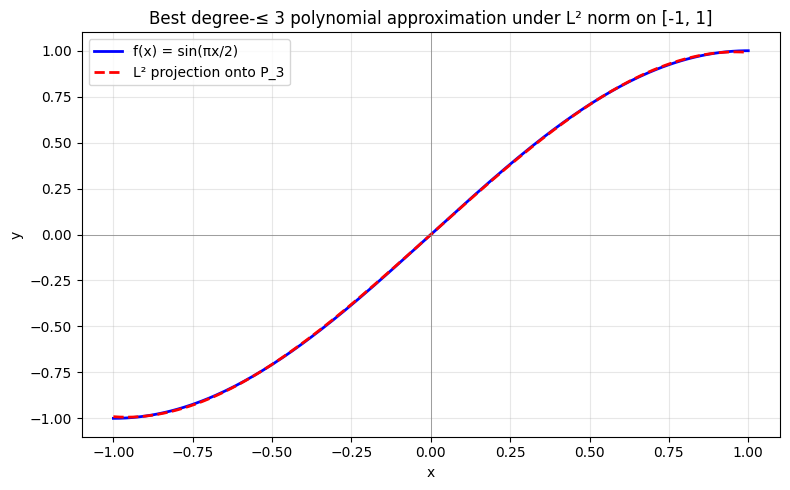

In [20]:
# Plot the function and its degree-3 L^2 projection
xs_plot = np.linspace(-1, 1, 200)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xs_plot, f(xs_plot), 'b-', lw=2, label='f(x) = sin(πx/2)')
ax.plot(xs_plot, P.polyval(xs_plot, proj_coeffs), 'r--', lw=2,
        label='L² projection onto P_3')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Best degree-≤ 3 polynomial approximation under L² norm on [-1, 1]')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Recap

We built the Ch 7 machinery in code:

- `gram_schmidt` produces an ONB from any column basis; `R = QᵀA` reads off the upper-triangular factor.
- `np.linalg.qr` gives the same Q (up to sign flips of columns) via Householder reflections.
- Least squares can be solved via normal equations `AᵀA x̂ = Aᵀ b` or via `R x̂ = Qᵀ b`. Both agree numerically when `A` is well-conditioned; **QR wins on stability** when `A` is ill-conditioned.
- The L² inner product `⟨f, g⟩ = ∫ f g dx` makes function spaces inner-product spaces, and Gram–Schmidt on monomials produces the Legendre polynomials. Best polynomial approximation of any continuous function reduces to projecting onto the span.

Chapter 8 introduces **determinants**, the signed-volume scalar that characterizes invertibility from one number — and sets up the **characteristic polynomial** for eigenvalues in Ch 9.